In [1]:
import micrograd
print(micrograd)

<module 'micrograd' from 'C:\\Users\\ASUS\\anaconda3\\Lib\\site-packages\\micrograd\\__init__.py'>


In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
def f(x):
    return 3*x**2 - 4*x + 5

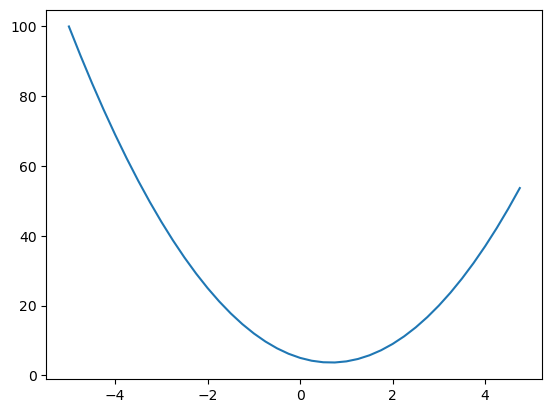

In [4]:
xs = np.arange(-5, 5, .25)
ys = f(xs)
ys
plt.plot(xs, ys)

In [5]:
h = 0.000000000001
x = 3.0
(f(x+h) - f(x))/h

14.001244608152774

In [6]:
h = 0.000000000001
x = -3.0 # the function will go down like below 20
(f(x+h) - f(x))/h

-21.9984030991327

In [7]:
h = 0.00000000001
x = 2/3 # at this precise point, if we nudge in the positive direction also the function doesn't change, and stays 0.0
(f(x+h) - f(x))/h

0.0

In [8]:
# lets get more complex : 3 scalar input => a,b,c and 1 output => d
a = 2.0
b = -3.0
c = 10.0
d = a*b+c
print(d)

4.0


In [9]:
h = 0.0001
# input
a = 2.0
b = -3.0
c = 10.0
d1 = a*b + c
#a += h
#b += h 
c += h
d2 = a*b + c #  at: a += h, value of the function will go down, slope will be negative
# but at: b += h, the value of the function will go up, slope will be positive
# at: c += h, we are making the value of the function slightly bit higher, slopw will be ~1, ie the rate at which d will increase as we scale c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h) # this difference between d1 and d2 is normalized by h, thats why we divided it by h

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [10]:
class Value:
    def __init__(self, data, _children=(), _op='', label='', x=0):
        self.data = data
        self.grad = 0.0 #the gradient is at 0 ie "on effect" meaning, at initialization this gradient doesn no effect to the output, 
        #ie change in variable is not changing the loss function
        self._backward = lambda: None
        self._prev= set(_children)
        self._op = _op
        self.label = label
        self.x = x
    def __repr__(self):
        return f"Value(data={self.data})"

    ''' all these below things we are going again because see, these things like add and multiply are already build in functions in python for
    python's defined object type int,float,double... etc, but this custom object that we created under the Value class required all these below to be 
    re defined as python doesn't know what to do with them, as it see them as "forein object" sort of, this is called operation overloading
    now we are again wrapping python add function with out defined add function for our this custom class objects'''
        
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward(): # let the function was a+b = c * d = f, so doing backword pass, we reach till c's grad value, now how much grad should go to a & b 
            self.grad += 1.0 * out.grad # da.grad = dc/da × c.grad & as we know d/dx of x is 1 that's why we do 1.0*c.grad
            other.grad += 1.0 * out.grad # db.grad = dc/db × c.grad
        out._backward = _backward # this means: "Store this function inside the output node"
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad # dc/da = b, now chain rule: da.grad = dc/da * c.grad
            other.grad += self.data * out.grad # dc/db = a, now chain rule: db.grad = dc/db * c.grad
        out._backward = _backward
        return out
    def __rmul__(self, other): # this is done because now after adding that if instance validation now we can multiple like a*2 but we still can't do 2*a
        #as python in the backend does 2.__mul__(a) and it getconfused as 2 can't multiply a value so to fix this we add this fallback
        #if python can't do 2*a it will check if a can multiply with 2 and if it can that it will redirect to rmul and it will correct it to a*2
        return self * other 

    def __pow__(self, other):
        assert isinstance(other, (int,float)), 'only supported for int or float powers for now'
        out = Value(self.data**other, (self,), f'**{other}')
        def _backward(): # d/dx of x^n = n * x^n-1
            self.grad += other * (self.data**(other-1)) * out.grad # here if we had done out.data(other-1) it would have been (x**2)**2-1
            # where we wanted to do x**2-1 only
        out._backward = _backward
        return out
    
    def __truediv__(self, other): # a/b = a* 1/b = a * b^-1 
        return self * other**-1

    def __neg__(self):
        return self *-1
    
    def __sub__(self, other):
        return self + (-other)

    def __radd__(self, other): # this is same as rmul but for addition
        return self + other
    
    def exp(self): # this mirrors tanh
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            self.grad += out.data * out.grad # so out.data is essential the e^x and out.grad the the chain rule's prev data, !
        out._backward = _backward
        return out

    def tanh(self): # tanh like other (relu, softmax) are called nonlinearlities or also called acitivation function
        x = self.data
        t = (math.exp(2*x)-1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad += (1-t**2) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev: # this is same as like, get into a cave, if there is a way inside that cave, explore it, and this loop repeats
                    build_topo(child)
                topo.append(v) # it is only gonna add it self, when all the childres are on the list
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label='e'
d = e+c; d.label='d'  #(a.__mul__(b)).__add__(c)
f = Value(-2.0, label='f')
L = d*f; L.label='L'
L

Value(data=-8.0)

In [11]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [12]:
d._op

'+'

In [13]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir':'LR'}) # LR = left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n)) # python stores the unique id for each variable, graphviz requires that as it accepts only unique values
        # draw a rectangle for any value in the graph, record is the name used in graphviz
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is the result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        #connect n1 to the op node for n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

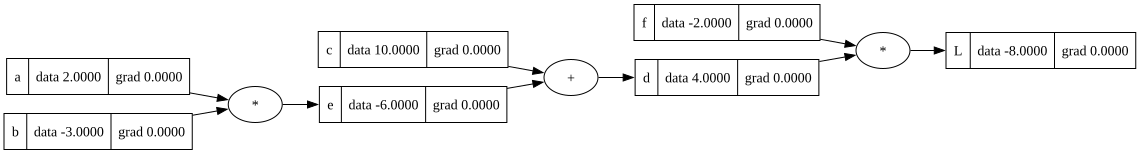

In [14]:
draw_dot(L) # this is what is called as a forward pass

In [15]:
# derivatice now

#L = d*f 
#f.grad = 4.0 # => dL/df = d(d*f)/df = d = 4.0
#similarly
#d.grad = -2.0

#dd/dc ? 1.0
#d = c+e
# d/dc of c+e is 1 + 0 = 1

# dl/ dc = dL/dd * dd/dc (chain rule)
# -2.0 * 1.0 = -2.0

In [16]:
a.grad = -2.0*-3.0
b.grad = -2.0 * 2.0
c.grad = -2.0 * 1.0
d.grad = -2.0
f.grad = 4.0
L.grad = 1.0

In [17]:
# below are these the leaf node (no parent node, only child)
a.data += 0.01 * a.grad # we are nudging values in the positive direction on L, ie the direction of the gradient
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a*b
d = e+c
L = d*f

print(L.data)

-7.286496


In [18]:
# now we are gonna do backpropagation mathematically
def lol():
    h = 0.001
    
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e+c; d.label='d' 
    f = Value(-2.0, label='f')
    L = d*f; L.label='L'
    L1 = L.data

    a = Value(2.0, label='a') 
    #a.data += h # dl/da = dL/dd * dd/de * de/da (chain rule)
    b = Value(-3.0, label='b')
    b.data += h
    c = Value(10.0, label='c')
    #c.data += h # dl/ dc = dL/dd * dd/dc (chain rule)
    e = a*b; e.label='e'
    d = e+c; d.label='d'
    # d.data += h => this is basically d.grad = -2.0 (value of f)
    f = Value(-2.0, label='f') # here if we do -2.0 + h then we will get f.grad only = 4.0 (value of d)
    L = d*f; L.label='L'
    L2 = L.data

    print((L2-L1)/h)

lol()

-3.9999999999995595


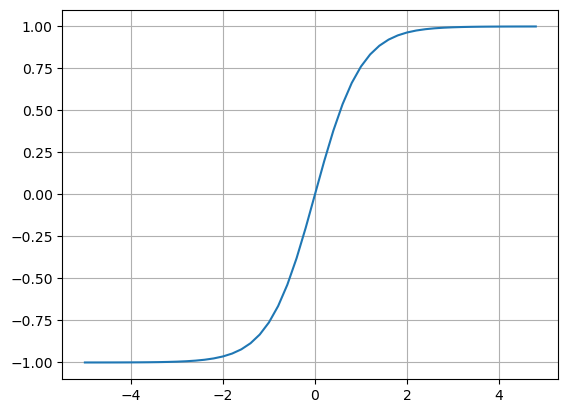

In [19]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid(); # tanh activation function

In [20]:
#inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
#weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.lable = 'o'

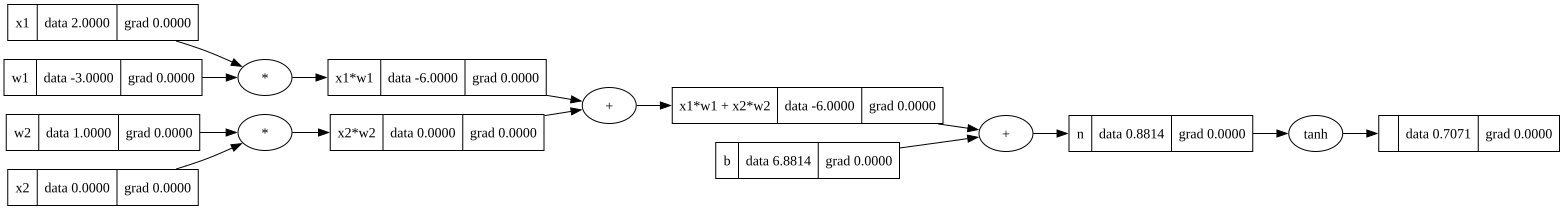

In [21]:
draw_dot(o)

In [22]:
o.grad = 1.0

In [23]:
# now we are going backward (backprop)
# o = tanh(n)
# d/dn(o) = 1-tanh**2 = 1-o**2
# n.grad = 1-o.data**2 = 0.4999999 => we use 0.5 (for better understanding
n.grad = 0.5

In [24]:
# now ever back, (chain rule)
# lets take 'x1w1x2w2' as a 
# n = (a+b), ie dn/da = d(a+b)/db = d/da of a = 1 & d/da of b = 0 => 0+1 = 1 
# similarly dn/db = d(a+b)/db = 1
# now using chain rule (visualize it as we went to the root, now doing d/dx to the top) => do/da  = do/dn * dn/da => 0.5000 * 1 = 0.5000
# similarly for do/db = do/dn * dn/db = 0.5000 * 1 = 0.5000
x1w1x2w2.grad = 0.5
b.grad = 0.5

In [25]:
# similarly next for x1w1 and x2*w2 
# d("x1w1+x2w2")/d("x1w1") = d("x1w1"+"x2w2")/d("x1w1") = 1
# same logic as above we get: 
#x1w1.grad = 0.5 * 1 * 1
#x2w2.grad = 0.5 * 1 * 1

x1w1.grad = 0.5
x2w2.grad = 0.5


In [26]:
x2.grad = w2.data * x2w2.grad # why not even back?! because it will result in the same number as x2w2.grad, its the same thing
#thunb rule, when doing d/dx of (a+b) its always 1, and for * operation its x1*w1 it will be the other like d/dx1 of (x1*w1) will be w1!
w2.grad = x2.data * x2w2.grad

In [27]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

In [28]:
# now we will do it bit more automatically using that above defined _backword function!!

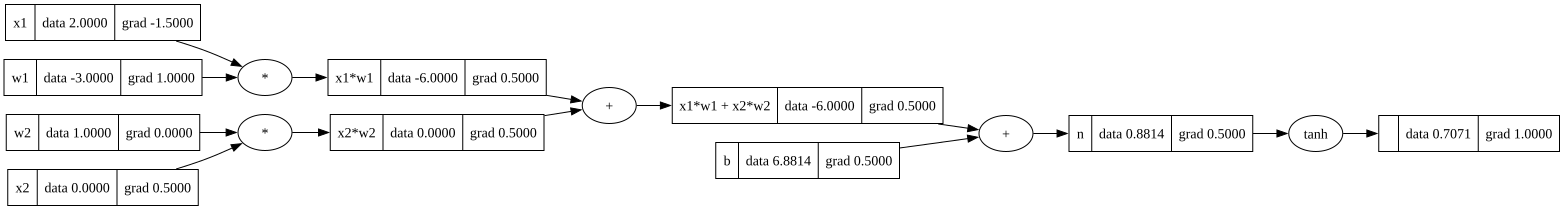

In [29]:
draw_dot(o)

In [30]:
o.grad=1.0

In [31]:
o._backward()# this will update the grad value of n!

In [32]:
n._backward() # this will update the grad of b and 'x1x2+x2w2'

In [33]:
x1w1x2w2._backward() # this will update the grad for x1w1 and x2w2

In [34]:
x1w1._backward()  # this will update the grad for x1 and w1

In [35]:
x2w2._backward() # this will update the grad for x2 and w2

In [36]:
# implimenting topological sort

topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev: # this is same as like, get into a cave, if there is a way inside that cave, explore it, and this loop repeats
            build_topo(child)
        topo.append(v) # it is only gonna add it self, when all the childres are on the list
build_topo(o)
topo # the last value will be our output value

[Value(data=6.881373587019543),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [37]:
# now lets do it using the backward function that we have just created!

In [38]:
o.backward()

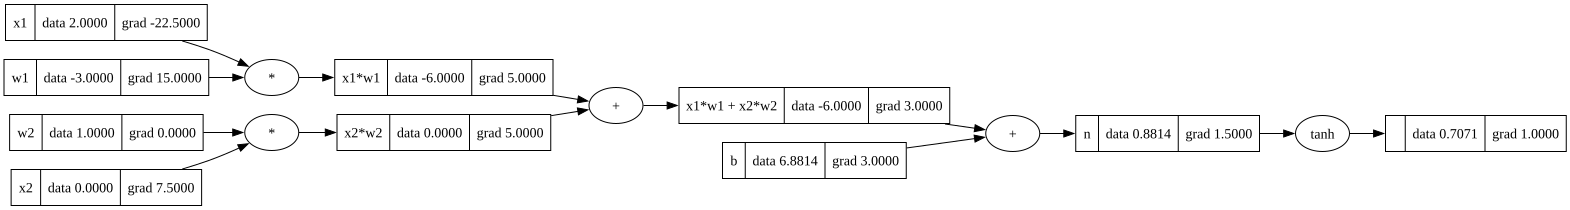

In [39]:
draw_dot(o)

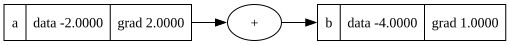

In [40]:
# the bug in our current program: it failed because till now we have not used a single variable multiple time over
a = Value(-2.0, label='a')
b = a+a; b.label='b'
b.backward()
draw_dot(b) # this is wrong, the a's gradient should be more , as d/da of (a+a) ie 2a = 2 * b.grad = 2*1 = 2 but this is giving a.grad = 1
# this is because of here: 
#def __add__(self, other):
        #out = Value(self.data + other.data, (self, other), '+')
        #def _backward()
            #self.grad = 1.0 * out.grad <- here we got 2
            #other.grad = 1.0 * out.grad <- again we are multiplying the b.grad (for ex) by 1, which should be multiplied by self.grad (or d/da grad)

In [41]:
a = Value(2.0)
a.exp()

Value(data=7.38905609893065)

In [42]:
a/b

Value(data=-0.5)

In [43]:
a**2

Value(data=4.0)

In [44]:
a-b

Value(data=6.0)

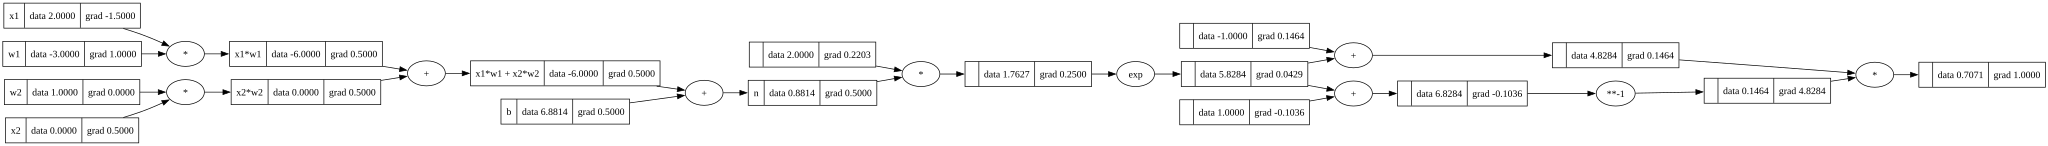

In [45]:
# now implimenting the tanh maunally

#inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
#weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# -----
e = (2*n).exp()
o = (e-1) / (e+1)
# -----
#o = n.tanh();o.lable = 'o'
o.lable = 'o'
o.backward()
draw_dot(o)

In [46]:
print(n.data)
print((2*n).data)
print(e.data)
print(o.data)

0.8813735870195432
1.7627471740390863
5.828427124746192
0.7071067811865477


In [47]:
!pip install torch

In [48]:
import torch

In [49]:

x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True # we do this required grad is because these all are leaf nodes, and by default pytorch doesn't get grad of these
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())# we do .item because it takes the first single element of that first single tensor and like pull out the element removing the tensor
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [50]:
torch.Tensor([2.0]).double().dtype #this will return at defualt float32 that single precision floating point number, python float are 64 so we do .double()

torch.float64

In [51]:
o.item()

0.7071066904050358

In [52]:
x2.item()

0.0

In [53]:
import random
class Neuron:
    def __init__ (self, nin): # nin are number of inputs the object will take in, this is used when defining an object of this class
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)] # these are the random weights
        self.b = Value(random.uniform(-1,1)) # these are the random weights

    def __call__(self, x):
        # w * x + b
        #act = sum(wi*xi for wi,xi in zip(self.w,x))+ self.b
        act = sum((wi*xi for wi,xi in zip(self.w,x)), self.b)# sum that another input too, ie the starting parameter, and we added the bias to there, so we no longer have to do + self.b
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout): # nout is how many no. of neurons we want
        self.neuron = [Neuron(nin) for _ in range(nout)] # that much number will be fed in while creating the Neuron class object

    def __call__(self, x):
        outs = [n(x) for n in self.neuron] # and that much time the input will be done
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neu in self.neuron for p in neu.parameters()]
        #params = []
        #for neu in self.neuron:
            #ps = neu/parameter()
            #params.extend(ps)
        #return params

class MLP: # multilayer perceptron

    def __init__(self, nin, nouts): # now instead of taking single amount of nouts, we are gonna take a list of nouts
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        

In [54]:
x = [2.0,3.0]
#n = Neuron(2) # this means that n that is the object of Neuron class will take in 2 inputs
n = Layer(2,3) # this 2 layer of neuron of each layer containing 3 neuron each
n(x) 

[Value(data=0.9993701489465867),
 Value(data=-0.8529487724080465),
 Value(data=0.7372894608434157)]

In [55]:
x = [2.0,3.0, -1.0]
n = MLP(3, [4,4,1])#so first layer has 3 input neuron, next 2 layer has bother 4 neuron and last one has just 1 output neuron!
n(x)

Value(data=-0.06433710683333417)

In [ ]:
n.parameters()

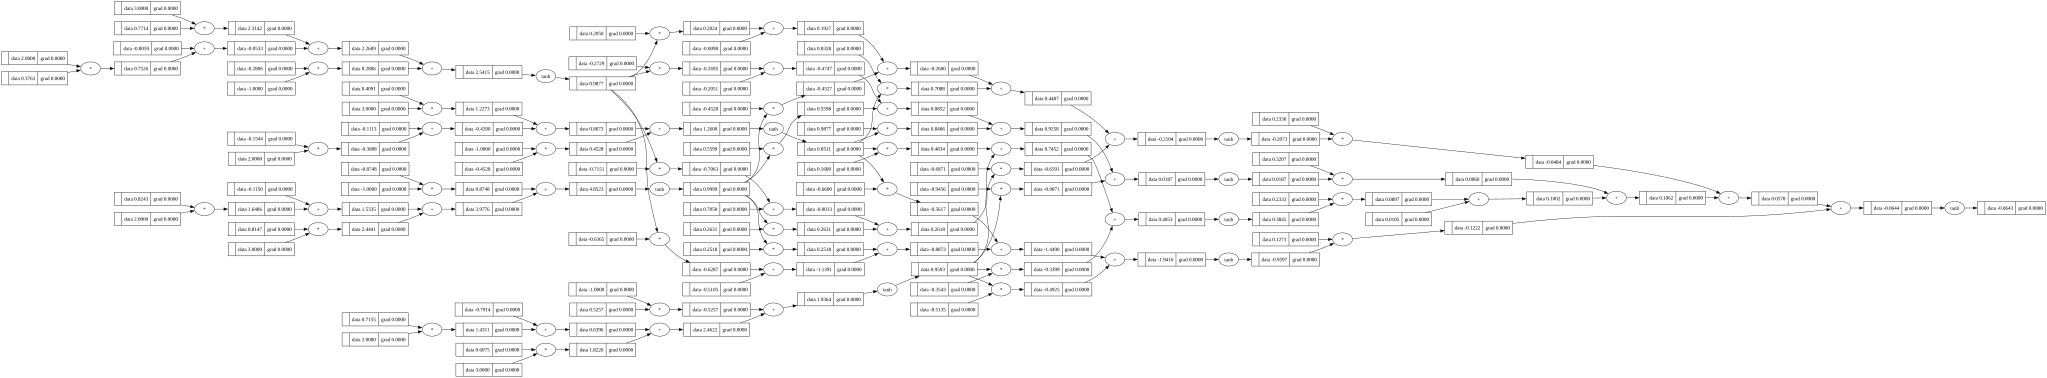

In [57]:
draw_dot(n(x))

In [58]:
# a simple dataset, this is a binary classification dataset 
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0],
]
ys  = [1.0, -1.0, -1.0, 1.0] # desired output

#we can test our current working model's output
ypred = [n(x) for x in xs]
ypred

[Value(data=-0.06433710683333417),
 Value(data=-0.3200464520118096),
 Value(data=-0.2990357448722131),
 Value(data=0.29046532703550704)]

In [59]:
# least square error
[(yout - ygt)**2 for ygt, yout in zip(ys, ypred)] # it becomes 0 when yout  = ygt (ygt = y ground truth)

[Value(data=1.1328134769823524),
 Value(data=0.4623368274217284),
 Value(data=0.49135088696685303),
 Value(data=0.5034394521388299)]

In [60]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=2.589940643509763)

In [61]:
loss.backward()

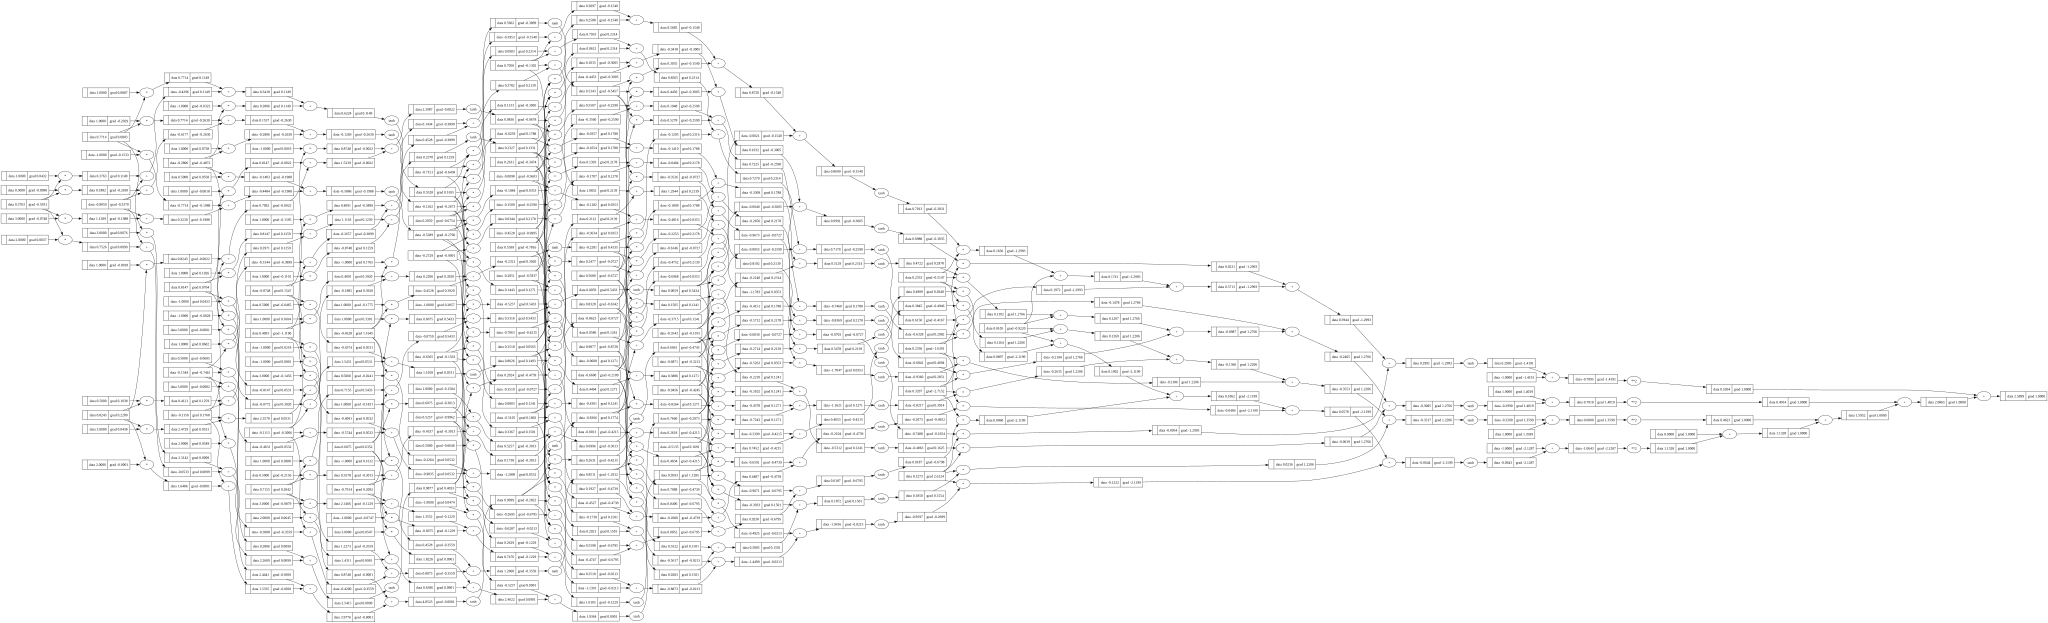

In [62]:
draw_dot(loss)

In [63]:
n.layers[0].neuron[0].w[0].grad

-0.5930897916546456

In [64]:
n.layers[0].neuron[0].w[0].data

0.37630179916286655

In [65]:
# Gradient Decent

In [66]:
for p in n.parameters():
    p.data += -0.01 * p.grad # so we are increasing the gradient which will decrease the difference but will increase the loss, 
    # this is the fundamental, if the value of the neuron goes lower, it will increase the loss but as we are trying to acheive 0.0 here
    # so we do -0.01 * p.grad (we add a - ve) as we eventually wants the loss to decrease not increase i.e increasing the neuron value

In [67]:
n.layers[0].neuron[0].w[0].grad

-0.5930897916546456

In [68]:
n.layers[0].neuron[0].w[0].data # now we slightly increase the neuron, to make the loss down

0.382232697079413

In [69]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss # now the loss has decreased from 3.8 to 3.5

Value(data=2.3072293053144226)

In [70]:
loss.backward()

In [71]:
for p in n.parameters():
    p.data += -0.01 * p.grad # the step that we too here, 0.01 this is sensitive, as if we take too bigger of a step then it might over step and the losses goes in negative
   # and this is what is called as a "learning rate" 

In [72]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss # now the loss has decreased from 3.8 to 3.5 to 3.04

Value(data=1.818670068500058)

In [73]:
ypred

[Value(data=0.14053332446345945),
 Value(data=-0.4121898063997891),
 Value(data=-0.3092592713874657),
 Value(data=0.49270962528574136)]

In [74]:
# implimenting a training loop so that we can make thing interative thing faster and automatic

In [75]:
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0],
]
ys  = [1.0, -1.0, -1.0, 1.0]

In [81]:
for k in range(20):
    #forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    #print(type(loss))
    
    #backward pass
    for p in n.parameters():
        p.grad = 0.0 # now we resets the grad to 0 so that the old grad doesn't pile up!, look below explaination first
    loss.backward()
    
    #print(loss)
    #print(loss._prev)
    #print(loss._op)

    #print("loss:", loss.data)

    #for i, p in enumerate(n.parameters()[:5]):
        #print(i, "data =", p.data, "grad =", p.grad)

    # update -> this is gradient decent
    for p in n.parameters():
        p.data += -0.05 * p.grad # here we are refreshing the data and making more or less, but that gradient isn't changed, 
        # so on the 2nd loop, that first grad vlaue just get added to the 2nd grad, and this keep going, and this is wrong 
        # that why we need to impliment .zero_grad() (this is pytorch one) using for loop
    #print(n.parameters()[0].data)
    print(k, loss.data)
    

0 0.019051141125950383
1 0.018510385187079606
2 0.017997980679760193
3 0.017511801711603582
4 0.0170499271623143
5 0.01661061680846398
6 0.016192290692923005
7 0.01579351123822097
8 0.015412967689200535
9 0.015049462540166477
10 0.014701899658647467
11 0.014369273864480578
12 0.014050661761228949
13 0.013745213648555436
14 0.013452146370374118
15 0.013170736975387228
16 0.012900317084805058
17 0.01264026787728027
18 0.012390015613891135
19 0.012149027636805119


In [82]:
ypred # perfect output we got

[Value(data=0.9360308330874894),
 Value(data=-0.9532548914190343),
 Value(data=-0.9290734130225121),
 Value(data=0.9709950451680571)]